In [1]:
import xarray as xr 
import numpy as np
import json
from datetime import date, timedelta
import os

In [ ]:
import glob

# ── fixed global 0.25° grid — labels are cell centers ────────────────────────
lat_grid = np.arange(-90.0,  90.0, 0.25)   # 720 centers: -90 … 89.75
lon_grid = np.arange(-180.0, 180.0, 0.25)  # 1440 centers: -180 … 179.75
nlat, nlon = len(lat_grid), len(lon_grid)
# true cell edges = center - 0.125
LAT_EDGE0 = lat_grid[0] - 0.125   # -90.125
LON_EDGE0 = lon_grid[0] - 0.125   # -180.125

# accumulators — initialised after first granule reveals n_spec
n_spec      = None
rad_sum     = None
unc_sum     = None
rad_cnt_arr = None
unc_cnt_arr = None
wl_mean     = None

# flat lists to collect all (cell_index, ctime) pairs across every granule
all_i_flat = []
all_ctimes = []

granule_files = sorted(glob.glob('./data/*.nc'))
print(f"Found {len(granule_files)} granule(s).")

for granule_path in granule_files:
	try:
		ds_g  = xr.load_dataset(granule_path, group='Radiance', engine='netcdf4')
		geo_g = xr.load_dataset(granule_path, group='Geometry', engine='netcdf4',
								decode_timedelta=False)
	except Exception as e:
		print(f"  skipping {os.path.basename(granule_path)}: {e}")
		continue

	lat2d = geo_g['latitude'].values    # (atrack, xtrack)
	lon2d = geo_g['longitude'].values

	# ctime may be (atrack,) or (atrack, xtrack); broadcast to pixel shape
	ctime = geo_g['ctime'].values
	if ctime.ndim == 1:
		ctime = np.broadcast_to(ctime[:, None], lat2d.shape).copy()

	# ── initialise accumulators from first valid granule ──────────────────
	if n_spec is None:
		n_spec      = ds_g.sizes['spectral']
		rad_sum     = np.zeros((nlat * nlon, n_spec), dtype=np.float64)
		unc_sum     = np.zeros((nlat * nlon, n_spec), dtype=np.float64)
		rad_cnt_arr = np.zeros((nlat * nlon, n_spec), dtype=np.int32)
		unc_cnt_arr = np.zeros((nlat * nlon, n_spec), dtype=np.int32)
		wl_mean     = ds_g['wavelength'].mean(dim='xtrack').values  # (spectral,)

	# ── mask to finite lat/lon pixels ─────────────────────────────────────
	valid     = np.isfinite(lat2d.ravel()) & np.isfinite(lon2d.ravel())
	lat_src   = lat2d.ravel()[valid]
	lon_src   = lon2d.ravel()[valid]
	ctime_src = ctime.ravel()[valid]
	rad_src   = ds_g['spectral_radiance'].values.reshape(-1, n_spec)[valid]
	unc_src   = ds_g['spectral_radiance_unc'].values.reshape(-1, n_spec)[valid]

	# ── compute flat grid-cell indices (floor against true cell edges) ────
	i_lat = np.floor((lat_src - LAT_EDGE0) / 0.25).astype(int)
	i_lon = np.floor((lon_src - LON_EDGE0) / 0.25).astype(int)
	in_bounds = (i_lat >= 0) & (i_lat < nlat) & (i_lon >= 0) & (i_lon < nlon)
	i_flat = i_lat[in_bounds] * nlon + i_lon[in_bounds]

	# ── accumulate radiance & uncertainty sums ────────────────────────────
	rad_in = rad_src[in_bounds]
	unc_in = unc_src[in_bounds]
	np.add.at(rad_sum,     i_flat, np.where(np.isfinite(rad_in), rad_in, 0.0))
	np.add.at(unc_sum,     i_flat, np.where(np.isfinite(unc_in), unc_in, 0.0))
	np.add.at(rad_cnt_arr, i_flat, np.isfinite(rad_in).astype(np.int32))
	np.add.at(unc_cnt_arr, i_flat, np.isfinite(unc_in).astype(np.int32))

	# ── stash flat cell index + ctime for the ragged time grid ────────────
	all_i_flat.append(i_flat)
	all_ctimes.append(ctime_src[in_bounds])

	print(f"  processed {os.path.basename(granule_path)}")

# ── mean radiance / uncertainty ───────────────────────────────────────────────
with np.errstate(invalid='ignore'):
	rad_bin = np.where(rad_cnt_arr > 0, rad_sum / rad_cnt_arr, np.nan) \
				.reshape(nlat, nlon, n_spec).astype(np.float32)
	unc_bin = np.where(unc_cnt_arr > 0, unc_sum / unc_cnt_arr, np.nan) \
				.reshape(nlat, nlon, n_spec).astype(np.float32)


# ── ragged time grid: shape (nlat, nlon), each cell holds a 1-D array ────────
all_i_flat = np.concatenate(all_i_flat)
all_ctimes = np.concatenate(all_ctimes)

order     = np.argsort(all_i_flat, kind='stable')
sorted_i  = all_i_flat[order]
sorted_ct = all_ctimes[order]

unique_cells, starts = np.unique(sorted_i, return_index=True)
ends = np.append(starts[1:], len(sorted_i))

time_grid = np.empty(nlat * nlon, dtype=object)
for k in range(nlat * nlon):
	time_grid[k] = np.array([], dtype=np.float64)
for cell, s, e in zip(unique_cells, starts, ends):
	time_grid[cell] = sorted_ct[s:e]
time_grid = time_grid.reshape(nlat, nlon)   # (720, 1440) of variable-length arrays

# ── xarray Dataset for the gridded radiance / uncertainty ────────────────────
ds_binned_all = xr.Dataset(
	{
		'wavelength':            (['spectral'], wl_mean),
		'spectral_radiance':     (['lat', 'lon', 'spectral'], rad_bin),
		'spectral_radiance_unc': (['lat', 'lon', 'spectral'], unc_bin),
	},
	coords={
		'lat':     (['lat'],     lat_grid, {'units': 'degrees_north'}),
		'lon':     (['lon'],     lon_grid, {'units': 'degrees_east'}),
		'spectral': np.arange(n_spec),
	},
)

print(ds_binned_all)
print(f"\ntime_grid shape : {time_grid.shape}")
print(f"Non-empty cells : {sum(len(time_grid[i,j]) > 0 for i in range(nlat) for j in range(nlon))}")

In [ ]:
granule_path = './test.nc'
ds = xr.load_dataset(granule_path, group = 'Radiance', engine='netcdf4')
geo = xr.load_dataset(granule_path, group = 'Geometry', engine='netcdf4')
# --- source coordinates ---
lat2d = geo['latitude'].values   # (atrack, xtrack)
lon2d = geo['longitude'].values  # (atrack, xtrack)

# --- define 0.25° target grid bounded by the data extent ---
# grid labels are cell centers; true cell edges = center ± 0.125°
lat_center_min = np.floor(np.nanmin(lat2d) * 4) / 4
lat_center_max = np.ceil(np.nanmax(lat2d) * 4) / 4
lon_center_min = np.floor(np.nanmin(lon2d) * 4) / 4
lon_center_max = np.ceil(np.nanmax(lon2d) * 4) / 4

lat_grid = np.arange(lat_center_min, lat_center_max - 1e-6, 0.25)  # cell centers
lon_grid = np.arange(lon_center_min, lon_center_max - 1e-6, 0.25)
lon_2d, lat_2d = np.meshgrid(lon_grid, lat_grid)
target_pts = np.column_stack([lat_2d.ravel(), lon_2d.ravel()])

# --- flatten source points, keep only finite lat/lon ---
valid = np.isfinite(lat2d.ravel()) & np.isfinite(lon2d.ravel())
src_pts = np.column_stack([lat2d.ravel()[valid], lon2d.ravel()[valid]])

# --- flatten radiance arrays to (n_pts, spectral) ---
n_spec = ds.sizes['spectral']
rad_src = ds['spectral_radiance'].values.reshape(-1, n_spec)[valid]
unc_src = ds['spectral_radiance_unc'].values.reshape(-1, n_spec)[valid]

# --- binning: assign each source point to the nearest cell center ---

lat_src = lat2d.ravel()[valid]
lon_src = lon2d.ravel()[valid]

nlat, nlon = len(lat_grid), len(lon_grid)

# edge of first cell = center - 0.125; floor against that edge
i_lat = np.floor((lat_src - (lat_center_min - 0.125)) / 0.25).astype(int)
i_lon = np.floor((lon_src - (lon_center_min - 0.125)) / 0.25).astype(int)
in_bounds = (i_lat >= 0) & (i_lat < nlat) & (i_lon >= 0) & (i_lon < nlon)
i_flat = i_lat[in_bounds] * nlon + i_lon[in_bounds]

rad_in = rad_src[in_bounds]
unc_in = unc_src[in_bounds]

rad_vals = np.where(np.isfinite(rad_in), rad_in, 0.0)
unc_vals = np.where(np.isfinite(unc_in), unc_in, 0.0)
rad_cnt  = np.isfinite(rad_in).astype(np.int32)
unc_cnt  = np.isfinite(unc_in).astype(np.int32)

rad_sum     = np.zeros((nlat * nlon, n_spec), dtype=np.float64)
unc_sum     = np.zeros((nlat * nlon, n_spec), dtype=np.float64)
rad_cnt_arr = np.zeros((nlat * nlon, n_spec), dtype=np.int32)
unc_cnt_arr = np.zeros((nlat * nlon, n_spec), dtype=np.int32)

np.add.at(rad_sum,     i_flat, rad_vals)
np.add.at(unc_sum,     i_flat, unc_vals)
np.add.at(rad_cnt_arr, i_flat, rad_cnt)
np.add.at(unc_cnt_arr, i_flat, unc_cnt)

with np.errstate(invalid='ignore'):
	rad_bin = np.where(rad_cnt_arr > 0, rad_sum / rad_cnt_arr, np.nan).reshape(nlat, nlon, n_spec).astype(np.float32)
	unc_bin = np.where(unc_cnt_arr > 0, unc_sum / unc_cnt_arr, np.nan).reshape(nlat, nlon, n_spec).astype(np.float32)

pt_count = np.zeros(nlat * nlon, dtype=np.int32)
np.add.at(pt_count, i_flat, 1)

wl_mean = ds['wavelength'].mean(dim='xtrack').values

ds_binned = xr.Dataset(
	{
		'wavelength':            (['spectral'], wl_mean),
		'spectral_radiance':     (['lat', 'lon', 'spectral'], rad_bin),
		'spectral_radiance_unc': (['lat', 'lon', 'spectral'], unc_bin),
		'count':                 (['lat', 'lon'], pt_count.reshape(nlat, nlon)),
	},
	coords={
		'lat': (['lat'], lat_grid, {'units': 'degrees_north'}),
		'lon': (['lon'], lon_grid, {'units': 'degrees_east'}),
		'spectral': np.arange(n_spec),
	},
)

ds_binned

/tmp/ipykernel_2388017/3416987309.py:3: FutureWarning: In a future version, xarray will not decode the variable 'ctime_minus_UTC' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  geo = xr.load_dataset(granule_path, group = 'Geometry', engine='netcdf4')


<xarray.Dataset> Size: 490MB
Dimensions:                (spectral: 63, lat: 670, lon: 1440)
Coordinates:
  * spectral               (spectral) int64 504B 0 1 2 3 4 5 ... 58 59 60 61 62
  * lat                    (lat) float64 5kB -83.75 -83.5 -83.25 ... 83.25 83.5
  * lon                    (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
Data variables:
    wavelength             (spectral) float32 252B nan nan nan ... 51.9 52.66
    spectral_radiance      (lat, lon, spectral) float32 243MB nan nan ... nan
    spectral_radiance_unc  (lat, lon, spectral) float32 243MB nan nan ... nan
    count                  (lat, lon) int32 4MB 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0

In [15]:
import glob
#Tried 0.1 deg resolution, but produced many empty values. 
# ── fixed global 0.25° grid — labels are cell centers ────────────────────────
lat_grid = np.arange(-90.0,  90.0, 0.25)   # 720 centers: -90 … 89.75
lon_grid = np.arange(-180.0, 180.0, 0.25)  # 1440 centers: -180 … 179.75
nlat, nlon = len(lat_grid), len(lon_grid)
# true cell edges = center - 0.125
LAT_EDGE0 = lat_grid[0] - 0.125   # -90.125
LON_EDGE0 = lon_grid[0] - 0.125   # -180.125

# accumulators — initialised after first granule reveals n_spec
n_spec      = None
rad_sum     = None
rad_sum_sq  = None   # for std: accumulates sum of x²
unc_sum     = None
rad_cnt_arr = None
unc_cnt_arr = None
wl_mean     = None

all_i_flat = []
all_ctimes = []

granule_files = sorted(glob.glob('./data/*.nc'))
print(f"Found {len(granule_files)} granule(s).")

for granule_path in granule_files:
	try:
		ds_g  = xr.load_dataset(granule_path, group='Radiance', engine='netcdf4')
		geo_g = xr.load_dataset(granule_path, group='Geometry', engine='netcdf4',
								decode_timedelta=False)
	except Exception as e:
		print(f"  skipping {os.path.basename(granule_path)}: {e}")
		continue

	lat2d = geo_g['latitude'].values
	lon2d = geo_g['longitude'].values

	ctime = geo_g['ctime'].values
	if ctime.ndim == 1:
		ctime = np.broadcast_to(ctime[:, None], lat2d.shape).copy()

	if n_spec is None:
		n_spec      = ds_g.sizes['spectral']
		rad_sum     = np.zeros((nlat * nlon, n_spec), dtype=np.float64)
		rad_sum_sq  = np.zeros((nlat * nlon, n_spec), dtype=np.float64)
		unc_sum     = np.zeros((nlat * nlon, n_spec), dtype=np.float64)
		rad_cnt_arr = np.zeros((nlat * nlon, n_spec), dtype=np.int32)
		unc_cnt_arr = np.zeros((nlat * nlon, n_spec), dtype=np.int32)
		wl_mean     = ds_g['wavelength'].mean(dim='xtrack').values

	valid     = np.isfinite(lat2d.ravel()) & np.isfinite(lon2d.ravel())
	lat_src   = lat2d.ravel()[valid]
	lon_src   = lon2d.ravel()[valid]
	ctime_src = ctime.ravel()[valid]
	rad_src   = ds_g['spectral_radiance'].values.reshape(-1, n_spec)[valid]
	unc_src   = ds_g['spectral_radiance_unc'].values.reshape(-1, n_spec)[valid]

	# mask out pixels where radiance_quality_flag is not 0 or 1
	qflag_src = ds_g['radiance_quality_flag'].values.reshape(-1, n_spec)[valid]
	rad_src   = np.where(np.isin(qflag_src, [0, 1]), rad_src, np.nan)

	i_lat = np.floor((lat_src - LAT_EDGE0) / 0.25).astype(int)
	i_lon = np.floor((lon_src - LON_EDGE0) / 0.25).astype(int)
	in_bounds = (i_lat >= 0) & (i_lat < nlat) & (i_lon >= 0) & (i_lon < nlon)
	i_flat = i_lat[in_bounds] * nlon + i_lon[in_bounds]

	rad_in      = rad_src[in_bounds]
	unc_in      = unc_src[in_bounds]
	rad_finite  = np.isfinite(rad_in)
	rad_vals    = np.where(rad_finite, rad_in, 0.0)
	
	np.add.at(rad_sum,     i_flat, rad_vals)
	np.add.at(rad_sum_sq,  i_flat, rad_vals ** 2)
	np.add.at(unc_sum,     i_flat, np.where(np.isfinite(unc_in), unc_in, 0.0))
	np.add.at(rad_cnt_arr, i_flat, rad_finite.astype(np.int32))
	np.add.at(unc_cnt_arr, i_flat, np.isfinite(unc_in).astype(np.int32))

	all_i_flat.append(i_flat)
	all_ctimes.append(ctime_src[in_bounds])

	print(f"  processed {os.path.basename(granule_path)}")

# ── mean, std, count ──────────────────────────────────────────────────────────
with np.errstate(invalid='ignore', divide='ignore'):
	rad_mean = np.where(rad_cnt_arr > 0, rad_sum / rad_cnt_arr, np.nan)
	# population std = sqrt(E[x²] - E[x]²); NaN for cells with <2 observations
	rad_var  = np.where(rad_cnt_arr > 1,
	                    rad_sum_sq / rad_cnt_arr - rad_mean ** 2,
	                    np.nan)
	rad_std  = np.sqrt(np.maximum(rad_var, 0.0))   # clamp tiny negatives from float rounding
	unc_mean = np.where(unc_cnt_arr > 0, unc_sum / unc_cnt_arr, np.nan)

rad_bin     = rad_mean.reshape(nlat, nlon, n_spec).astype(np.float32)
rad_std_bin = rad_std.reshape(nlat, nlon, n_spec).astype(np.float32)
rad_cnt_bin = rad_cnt_arr.reshape(nlat, nlon, n_spec)
unc_bin     = unc_mean.reshape(nlat, nlon, n_spec).astype(np.float32)

# ── ragged time grid ──────────────────────────────────────────────────────────
all_i_flat = np.concatenate(all_i_flat)
all_ctimes = np.concatenate(all_ctimes)

order     = np.argsort(all_i_flat, kind='stable')
sorted_i  = all_i_flat[order]
sorted_ct = all_ctimes[order]

unique_cells, starts = np.unique(sorted_i, return_index=True)
ends = np.append(starts[1:], len(sorted_i))

time_grid = np.empty(nlat * nlon, dtype=object)
for k in range(nlat * nlon):
	time_grid[k] = np.array([], dtype=np.float64)
for cell, s, e in zip(unique_cells, starts, ends):
	time_grid[cell] = sorted_ct[s:e]
time_grid = time_grid.reshape(nlat, nlon)

# ── xarray Dataset ────────────────────────────────────────────────────────────
ds_binned_all = xr.Dataset(
	{
		'wavelength':              (['spectral'], wl_mean, {'units': 'nm'}),
		'spectral_radiance':       (['lat', 'lon', 'spectral'], rad_bin, 
			{'long_name': 'Spectral Radiance', 'units': 'W/m²/sr/nm'}),
		'spectral_radiance_std':   (['lat', 'lon', 'spectral'], rad_std_bin, 
			{'long_name': 'Spectral Radiance Standard Deviation', 'units': 'W/m**2/sr/nm'}),
		'spectral_radiance_count': (['lat', 'lon', 'spectral'], rad_cnt_bin, 
			{'long_name': 'Spectral Radiance Count', 'units': 'count'}),
		'spectral_radiance_unc':   (['lat', 'lon', 'spectral'], unc_bin, 
			{'long_name': 'Spectral Radiance Uncertainty', 'units': 'W/m**2/sr/nm'}),
	},
	coords={
		'lat':      (['lat'],     lat_grid, {'units': 'degrees_north'}),
		'lon':      (['lon'],     lon_grid, {'units': 'degrees_east'}),
		'spectral': np.arange(n_spec),
	},
	attrs={
		'description': "Gridded mean, std, count of spectral radiance and mean spectral radiance uncertainty, "
		"binned to a 0.1° global grid. Each cell's time_grid entry lists the ctimes of all observations that contributed to that cell.",
	},
)
print(ds_binned_all)
print(f"\ntime_grid shape : {time_grid.shape}")
print(f"Non-empty cells : {sum(len(time_grid[i,j]) > 0 for i in range(nlat) for j in range(nlon))}")

Found 200 granule(s).
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251117114759_08038.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251117132243_08039.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251117145728_08040.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251117163212_08041.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251117180657_08042.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251117194142_08043.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251117211626_08044.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251117225110_08045.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251118002554_08046.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251118020039_08047.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251118033524_08048.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251118051008_08049.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251118064452_08050.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251118081936_08051.nc
  processed PREFIRE_SAT1_1B-RAD_R01_P00_20251118095421_08052.nc
  processed PREFIR

In [34]:
np.save('time_grid.npy', time_grid, allow_pickle=True)

# to reload:
# time_grid = np.load('time_grid.npy', allow_pickle=True)

In [ ]:
time_grid1 = np.load('time_grid.npy', allow_pickle=True) #Allow pickle to load arrays of variable-length arrays
time_grid1

array([[array([], dtype=float64), array([], dtype=float64),
        array([], dtype=float64), ..., array([], dtype=float64),
        array([], dtype=float64), array([], dtype=float64)],
       [array([], dtype=float64), array([], dtype=float64),
        array([], dtype=float64), ..., array([], dtype=float64),
        array([], dtype=float64), array([], dtype=float64)],
       [array([], dtype=float64), array([], dtype=float64),
        array([], dtype=float64), ..., array([], dtype=float64),
        array([], dtype=float64), array([], dtype=float64)],
       ...,
       [array([], dtype=float64), array([], dtype=float64),
        array([], dtype=float64), ..., array([], dtype=float64),
        array([], dtype=float64), array([], dtype=float64)],
       [array([], dtype=float64), array([], dtype=float64),
        array([], dtype=float64), ..., array([], dtype=float64),
        array([], dtype=float64), array([], dtype=float64)],
       [array([], dtype=float64), array([], dtype=float64)

In [16]:
ds_binned_all.to_netcdf('2512RAD.nc')

In [7]:
ds_binned_all

<xarray.Dataset> Size: 7GB
Dimensions:                  (spectral: 63, lat: 1800, lon: 3600)
Coordinates:
  * spectral                 (spectral) int64 504B 0 1 2 3 4 ... 58 59 60 61 62
  * lat                      (lat) float64 14kB -90.0 -89.9 -89.8 ... 89.8 89.9
  * lon                      (lon) float64 29kB -180.0 -179.9 ... 179.8 179.9
Data variables:
    wavelength               (spectral) float32 252B nan nan nan ... 51.9 52.66
    spectral_radiance        (lat, lon, spectral) float32 2GB nan nan ... nan
    spectral_radiance_std    (lat, lon, spectral) float32 2GB nan nan ... nan
    spectral_radiance_count  (lat, lon, spectral) int32 2GB 0 0 0 0 ... 0 0 0 0
    spectral_radiance_unc    (lat, lon, spectral) float32 2GB nan nan ... nan

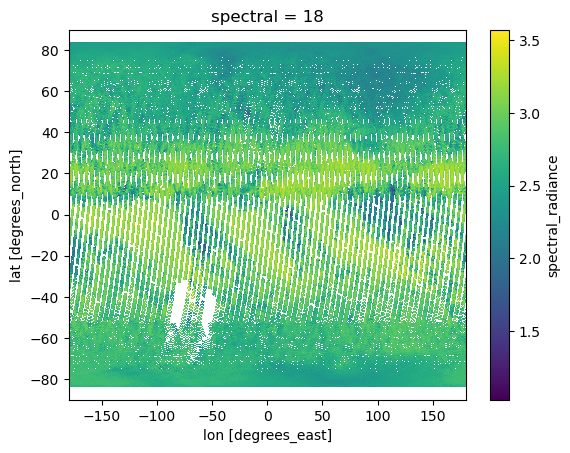

In [ ]:
#Effect when you have 0.25 grid
ds_binned = xr.load_dataset('2512RAD.nc')
ds_binned.isel(spectral = 18).spectral_radiance.plot()

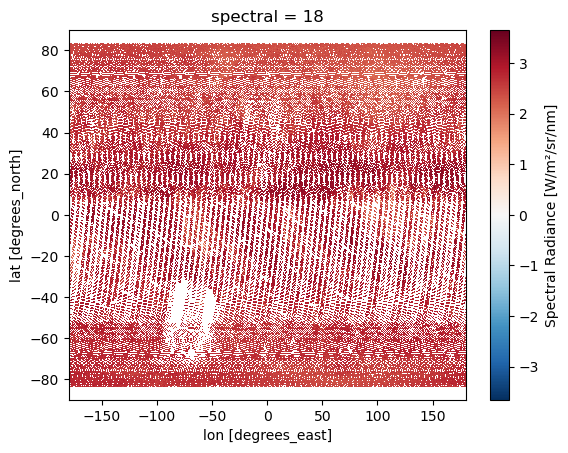

In [ ]:
#Effect when you have 0.1 grid
ds_binned_all.isel(spectral = 18).spectral_radiance.plot()

In [17]:
ds_binned_all

<xarray.Dataset> Size: 1GB
Dimensions:                  (spectral: 63, lat: 720, lon: 1440)
Coordinates:
  * spectral                 (spectral) int64 504B 0 1 2 3 4 ... 58 59 60 61 62
  * lat                      (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75
  * lon                      (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
Data variables:
    wavelength               (spectral) float32 252B nan nan nan ... 51.9 52.66
    spectral_radiance        (lat, lon, spectral) float32 261MB nan nan ... nan
    spectral_radiance_std    (lat, lon, spectral) float32 261MB nan nan ... nan
    spectral_radiance_count  (lat, lon, spectral) int32 261MB 0 0 0 0 ... 0 0 0
    spectral_radiance_unc    (lat, lon, spectral) float32 261MB nan nan ... nan
Attributes:
    description:  Gridded mean, std, count of spectral radiance and mean spec...

In [36]:
map = np.zeros((nlat, nlon), dtype=np.int32)
for lat_idx, lat in enumerate(time_grid1):
	for time_idx, time in enumerate(lat):
		map[lat_idx, time_idx] = int(time.shape[0])
		
map

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(720, 1440), dtype=int32)

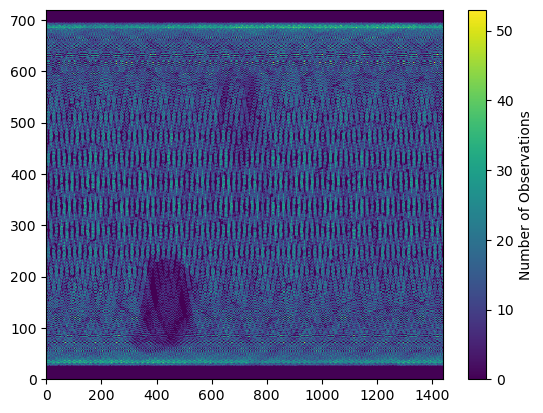

In [37]:
import matplotlib.pyplot as plt
clb = plt.pcolormesh(map, shading='auto')
plt.colorbar(clb, label='Number of Observations')
plt.show()